In [1]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Load dataset
df = pd.read_csv("UpdatedResumeDataSet.csv")

# Preprocess text
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)   # keep only letters
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

df['Cleaned_Resume'] = df['Resume'].apply(clean_text)

# Features & labels
X = df['Cleaned_Resume']
y = df['Category']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Train model
clf = LogisticRegression(max_iter=2000)
clf.fit(X_train_tfidf, y_train)

# Evaluate
y_pred = clf.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


[nltk_data] Downloading package stopwords to /home/manoj/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Accuracy: 0.9948186528497409
                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         3
                     Arts       1.00      1.00      1.00         6
       Automation Testing       1.00      1.00      1.00         5
               Blockchain       1.00      1.00      1.00         7
         Business Analyst       1.00      1.00      1.00         4
           Civil Engineer       1.00      1.00      1.00         9
             Data Science       1.00      1.00      1.00         5
                 Database       1.00      1.00      1.00         8
          DevOps Engineer       1.00      0.93      0.96        14
         DotNet Developer       1.00      1.00      1.00         5
            ETL Developer       1.00      1.00      1.00         7
   Electrical Engineering       1.00      1.00      1.00         6
                       HR       1.00      1.00      1.00        12
                   Hadoop       

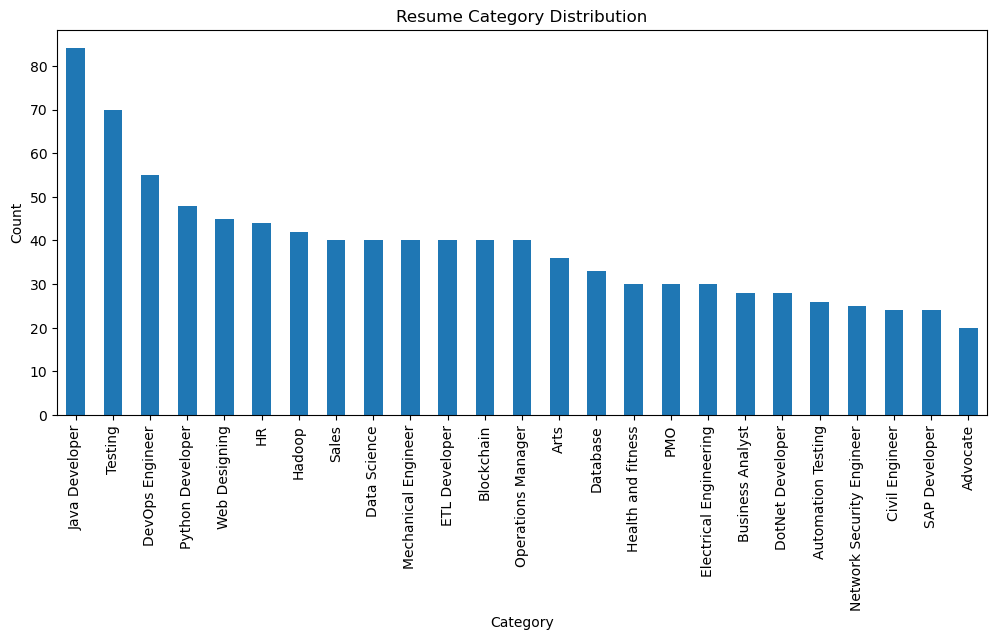

In [2]:
import matplotlib.pyplot as plt

df['Category'].value_counts().plot(kind='bar', figsize=(12,5))
plt.title("Resume Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()


In [4]:
!pip install wordcloud


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 537.2/537.2 kB 393.2 kB/s eta 0:00:0031m? eta -:--:--


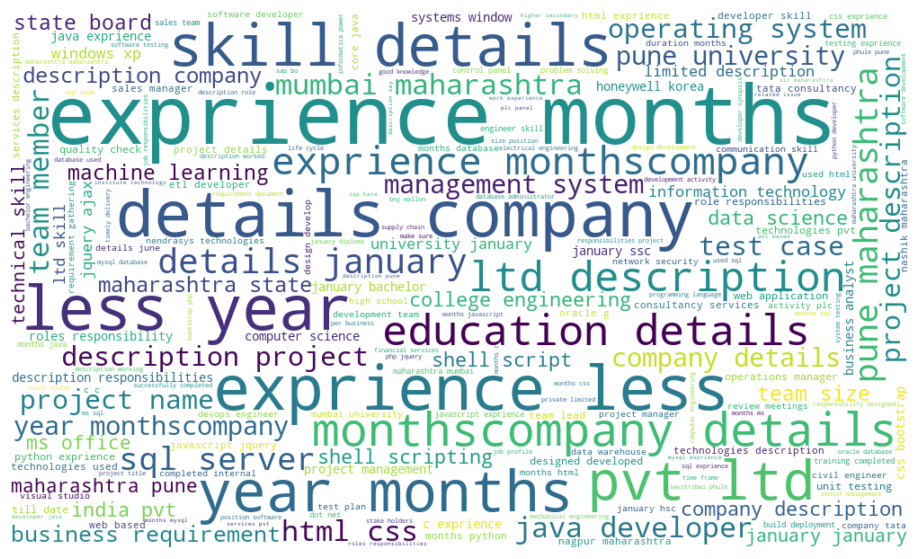

In [5]:
from wordcloud import WordCloud

# Combine all cleaned resumes
all_words = ' '.join(df['Cleaned_Resume'])

wordcloud = WordCloud(width=1000, height=600, background_color='white').generate(all_words)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()


In [6]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

# Train SVM model
svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)

# Predictions
y_pred_svm = svm.predict(X_test_tfidf)

# Evaluation
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


SVM Accuracy: 0.9948186528497409
                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         3
                     Arts       1.00      1.00      1.00         6
       Automation Testing       1.00      1.00      1.00         5
               Blockchain       1.00      1.00      1.00         7
         Business Analyst       1.00      1.00      1.00         4
           Civil Engineer       1.00      1.00      1.00         9
             Data Science       1.00      1.00      1.00         5
                 Database       1.00      1.00      1.00         8
          DevOps Engineer       1.00      0.93      0.96        14
         DotNet Developer       1.00      1.00      1.00         5
            ETL Developer       1.00      1.00      1.00         7
   Electrical Engineering       1.00      1.00      1.00         6
                       HR       1.00      1.00      1.00        12
                   Hadoop   

In [3]:
import joblib

# Save the best model (SVM here)
joblib.dump(svm, "resume_svm_model.pkl")

# Save TF-IDF vectorizer
joblib.dump(tfidf, "tfidf_vectorizer.pkl")


NameError: name 'svm' is not defined

In [15]:
# Load model and vectorizer
loaded_model = joblib.load("resume_svm_model.pkl")
loaded_tfidf = joblib.load("tfidf_vectorizer.pkl")

# Example new resume
new_resume = """Experienced in Python, Machine Learning, Data Analysis, 
                SQL, and building predictive models. Worked on NLP projects."""
                
# Preprocess + transform
new_resume_cleaned = clean_text(new_resume)
new_resume_tfidf = loaded_tfidf.transform([new_resume_cleaned])

# Predict
prediction = loaded_model.predict(new_resume_tfidf)
print("Predicted Category:", prediction[0])


Predicted Category: Data Science


In [14]:
'''import pandas as pd
import random

# Sample data
names = ["Alice", "Bob", "Charlie", "David", "Eva", "Frank", "Grace", "Hannah", "Ivan", "Julia"]
roles = ["Machine Learning", "Web Development", "Data Science", "Machine Learning", "Web Development",
         "Machine Learning", "Data Science", "Machine Learning", "Web Development", "Machine Learning"]
skills_ml = ["Python, ML, NLP, Computer Vision", "Python, Deep Learning, TensorFlow", "Python, ML, Data Analysis",
             "Python, ML, PyTorch", "Python, ML, AI Projects"]
skills_web = ["HTML, CSS, JavaScript, React", "JavaScript, Node.js, Express", "HTML, CSS, Django", "React, Angular, JS"]
skills_ds = ["Python, SQL, Data Analysis", "Python, Pandas, Visualization"]

# Create resumes
resumes = []
for i in range(10):
    role = roles[i]
    if role == "Machine Learning":
        skills = random.choice(skills_ml)
        experience = random.randint(2, 8)  # years of experience
    elif role == "Web Development":
        skills = random.choice(skills_web)
        experience = random.randint(1, 5)
    else:
        skills = random.choice(skills_ds)
        experience = random.randint(2, 6)
    
    resume_text = f"{names[i]} - {role} professional with {experience} years experience. Skills: {skills}."
    resumes.append({"Resume_Text": resume_text, "Role": role, "Experience": experience})

# Convert to DataFrame
df = pd.DataFrame(resumes)

# Filter Machine Learning resumes and take top 5 by experience
ml_resumes = df[df['Role'] == 'Machine Learning'].sort_values(by='Experience', ascending=False).head(5)

# Display top 5 ML resumes
for index, row in ml_resumes.iterrows():
    print(f"Resume {index+1} (Role: {row['Role']}, Experience: {row['Experience']} years):")
    print(row['Resume_Text'])
    print("-" * 50)'''


'import pandas as pd\nimport random\n\n# Sample data\nnames = ["Alice", "Bob", "Charlie", "David", "Eva", "Frank", "Grace", "Hannah", "Ivan", "Julia"]\nroles = ["Machine Learning", "Web Development", "Data Science", "Machine Learning", "Web Development",\n         "Machine Learning", "Data Science", "Machine Learning", "Web Development", "Machine Learning"]\nskills_ml = ["Python, ML, NLP, Computer Vision", "Python, Deep Learning, TensorFlow", "Python, ML, Data Analysis",\n             "Python, ML, PyTorch", "Python, ML, AI Projects"]\nskills_web = ["HTML, CSS, JavaScript, React", "JavaScript, Node.js, Express", "HTML, CSS, Django", "React, Angular, JS"]\nskills_ds = ["Python, SQL, Data Analysis", "Python, Pandas, Visualization"]\n\n# Create resumes\nresumes = []\nfor i in range(10):\n    role = roles[i]\n    if role == "Machine Learning":\n        skills = random.choice(skills_ml)\n        experience = random.randint(2, 8)  # years of experience\n    elif role == "Web Development":\n  

In [13]:
'''from ipywidgets import FileUpload
from IPython.display import display

# Create upload widget
uploader = FileUpload(
    accept='.pdf',  # only PDF files
    multiple=True
)
display(uploader)'''


"from ipywidgets import FileUpload\nfrom IPython.display import display\n\n# Create upload widget\nuploader = FileUpload(\n    accept='.pdf',  # only PDF files\n    multiple=True\n)\ndisplay(uploader)"

In [12]:
'''import os

folder = "resumes"
os.makedirs(folder, exist_ok=True)

if len(uploader.value) == 0:
    print("No files uploaded yet! Please upload first.")
else:
    for uploaded_file in uploader.value:  # iterate over uploaded files
        filename = uploaded_file['name']
        content = uploaded_file['content']
        with open(os.path.join(folder, filename), "wb") as f:
            f.write(content)
    
    print(f"{len(uploader.value)} resumes uploaded successfully to '{folder}' folder!")'''



'import os\n\nfolder = "resumes"\nos.makedirs(folder, exist_ok=True)\n\nif len(uploader.value) == 0:\n    print("No files uploaded yet! Please upload first.")\nelse:\n    for uploaded_file in uploader.value:  # iterate over uploaded files\n        filename = uploaded_file[\'name\']\n        content = uploaded_file[\'content\']\n        with open(os.path.join(folder, filename), "wb") as f:\n            f.write(content)\n    \n    print(f"{len(uploader.value)} resumes uploaded successfully to \'{folder}\' folder!")'

In [26]:
!pip install PyPDF2


In [11]:
# Step 3: Extract text and filter Machine Learning resumes
'''import PyPDF2
import pandas as pd
import re

resume_data = []

for filename in os.listdir(folder):
    if filename.endswith(".pdf"):
        path = os.path.join(folder, filename)
        pdf_file = open(path, "rb")
        reader = PyPDF2.PdfReader(pdf_file)
        text = ""
        for page in reader.pages:
            text += page.extract_text() + " "
        pdf_file.close()
        
        # Detect role/category
        role = "Machine Learning" if "Machine Learning" in text else "Other"
        
        # Extract experience (regex: 'Experience: X years')
        match = re.search(r'Experience[:\s]+(\d+)', text)
        experience = int(match.group(1)) if match else 0
        
        resume_data.append({
            "File": filename,
            "Text": text,
            "Role": role,
            "Experience": experience
        })

# Convert to DataFrame
df = pd.DataFrame(resume_data)'''


'import PyPDF2\nimport pandas as pd\nimport re\n\nresume_data = []\n\nfor filename in os.listdir(folder):\n    if filename.endswith(".pdf"):\n        path = os.path.join(folder, filename)\n        pdf_file = open(path, "rb")\n        reader = PyPDF2.PdfReader(pdf_file)\n        text = ""\n        for page in reader.pages:\n            text += page.extract_text() + " "\n        pdf_file.close()\n        \n        # Detect role/category\n        role = "Machine Learning" if "Machine Learning" in text else "Other"\n        \n        # Extract experience (regex: \'Experience: X years\')\n        match = re.search(r\'Experience[:\\s]+(\\d+)\', text)\n        experience = int(match.group(1)) if match else 0\n        \n        resume_data.append({\n            "File": filename,\n            "Text": text,\n            "Role": role,\n            "Experience": experience\n        })\n\n# Convert to DataFrame\ndf = pd.DataFrame(resume_data)'

In [10]:
# Step 4: Filter Machine Learning resumes and get top 5 by experience
'''ml_resumes = df[df['Role'] == 'Machine Learning']
top_5_ml = ml_resumes.sort_values(by='Experience', ascending=False).head(5)

# Display top 5 Machine Learning resumes
print("Top 5 Machine Learning Candidates:\n")
for index, row in top_5_ml.iterrows():
    print(f"Resume: {row['File']}")
    print(f"Experience: {row['Experience']} years")
    print(f"Role: {row['Role']}")
    print("-" * 50)'''


'ml_resumes = df[df[\'Role\'] == \'Machine Learning\']\ntop_5_ml = ml_resumes.sort_values(by=\'Experience\', ascending=False).head(5)\n\n# Display top 5 Machine Learning resumes\nprint("Top 5 Machine Learning Candidates:\n")\nfor index, row in top_5_ml.iterrows():\n    print(f"Resume: {row[\'File\']}")\n    print(f"Experience: {row[\'Experience\']} years")\n    print(f"Role: {row[\'Role\']}")\n    print("-" * 50)'

In [16]:
# streamlit_upload_resumes.py
'''import streamlit as st
import os

st.title("Upload Resumes")

# Create folder to save resumes
folder = "resumes"
os.makedirs(folder, exist_ok=True)

# File uploader (allow multiple PDFs)
uploaded_files = st.file_uploader(
    "Upload PDF resumes",
    type=["pdf"],
    accept_multiple_files=True
)

if uploaded_files:
    for uploaded_file in uploaded_files:
        file_path = os.path.join(folder, uploaded_file.name)
        # Save file to folder
        with open(file_path, "wb") as f:
            f.write(uploaded_file.getbuffer())
    st.success(f"{len(uploaded_files)} resumes uploaded successfully to '{folder}' folder!")'''


'import streamlit as st\nimport os\n\nst.title("Upload Resumes")\n\n# Create folder to save resumes\nfolder = "resumes"\nos.makedirs(folder, exist_ok=True)\n\n# File uploader (allow multiple PDFs)\nuploaded_files = st.file_uploader(\n    "Upload PDF resumes",\n    type=["pdf"],\n    accept_multiple_files=True\n)\n\nif uploaded_files:\n    for uploaded_file in uploaded_files:\n        file_path = os.path.join(folder, uploaded_file.name)\n        # Save file to folder\n        with open(file_path, "wb") as f:\n            f.write(uploaded_file.getbuffer())\n    st.success(f"{len(uploaded_files)} resumes uploaded successfully to \'{folder}\' folder!")'

In [17]:
# streamlit_upload_resumes.py
'''import streamlit as st
import os

st.title("Upload Resumes")

# Create folder to save resumes
folder = "resumes"
os.makedirs(folder, exist_ok=True)

# File uploader (allow multiple PDFs)
uploaded_files = st.file_uploader(
    "Upload PDF resumes",
    type=["pdf"],
    accept_multiple_files=True
)

if uploaded_files:
    for uploaded_file in uploaded_files:
        file_path = os.path.join(folder, uploaded_file.name)
        # Save file to folder
        with open(file_path, "wb") as f:
            f.write(uploaded_file.getbuffer())
    st.success(f"{len(uploaded_files)} resumes uploaded successfully to '{folder}' folder!")'''


'import streamlit as st\nimport os\n\nst.title("Upload Resumes")\n\n# Create folder to save resumes\nfolder = "resumes"\nos.makedirs(folder, exist_ok=True)\n\n# File uploader (allow multiple PDFs)\nuploaded_files = st.file_uploader(\n    "Upload PDF resumes",\n    type=["pdf"],\n    accept_multiple_files=True\n)\n\nif uploaded_files:\n    for uploaded_file in uploaded_files:\n        file_path = os.path.join(folder, uploaded_file.name)\n        # Save file to folder\n        with open(file_path, "wb") as f:\n            f.write(uploaded_file.getbuffer())\n    st.success(f"{len(uploaded_files)} resumes uploaded successfully to \'{folder}\' folder!")'